In [38]:
import os
import json
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

# Set random seed for strict reproducibility
torch.manual_seed(42)
random.seed(42)

# Download dataset via kagglehub
dataset_path = kagglehub.dataset_download('giorgicheishvili/georgian-spellchecker-dataset')
print(f"Dataset downloaded and cached at: {dataset_path}")

Dataset downloaded and cached at: /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset


In [39]:
# Resolve precise paths inside the downloaded folder
csv_path = os.path.join(dataset_path, 'georgian_spellchecker_dataset.csv')
vocab_path = os.path.join(dataset_path, 'georgian_vocabulary.txt')

# Load dataset
df = pd.read_csv(csv_path)
print(f"Loaded dataset with {len(df):,} total pairs.")

# Display example pairs (Requirement: Show examples!)
print("\n--- Example Data Pairs (Input -> Target Target) ---")
print(df.head(10).to_string(index=False))

# Load valid Georgian words list 
with open(vocab_path, 'r', encoding='utf-8') as f:
    georgian_vocab_words = [line.strip() for line in f if line.strip()]
print(f"\nLoaded {len(georgian_vocab_words):,} words from the vocabulary text file.")

Loaded dataset with 332,132 total pairs.

--- Example Data Pairs (Input -> Target Target) ---
  input_word  target_word
  მეტრევეელს    მეტრეველს
     ეთნიკურ      ეთნიკურ
        რემი         ერმი
      ჰარჯკი       ჰარუკი
დაუნდობლობოს დაუნდობლობის
       ჯაჭვი       ჯაჭვში
   მოუუვიდათ     მოუვიდათ
    თვითონვე     თვითონვე
    დმნაისიც     დმანისიც
      ნახხავ        ნახავ

Loaded 110,734 words from the vocabulary text file.


In [40]:
PAD_TOKEN = '<PAD>'  # Padding token for shorter words
SOS_TOKEN = '<SOS>'  # Start of sequence
EOS_TOKEN = '<EOS>'  # End of sequence
UNK_TOKEN = '<UNK>'  # Unknown character fallback

# Collect all unique characters present across both columns
unique_chars = set()
for col in ['input_word', 'target_word']:
    for word in df[col].astype(str):
        unique_chars.update(list(word))

# Create unified vocabulary lookup tables
special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab = special_tokens + sorted(list(unique_chars))

char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = {idx: char for char, idx in char2idx.items()}

print(f"Character vocabulary size (including special tokens): {len(vocab)}")

# Save mapping dictionaries as metadata for inference.ipynb
vocab_metadata = {'char2idx': char2idx, 'idx2char': idx2char}
with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_metadata, f, ensure_ascii=False)
print("Saved 'vocab.json' to current working directory.")

Character vocabulary size (including special tokens): 42
Saved 'vocab.json' to current working directory.


In [41]:
class GeorgianSpellDataset(Dataset):
    def __init__(self, dataframe, char2idx_map):
        # Convert df columns to lists for faster iteration
        self.inputs = dataframe['input_word'].astype(str).tolist()
        self.targets = dataframe['target_word'].astype(str).tolist()
        self.char2idx = char2idx_map

    def __len__(self):
        return len(self.inputs)

    def encode(self, word):
        return [self.char2idx.get(char, self.char2idx[UNK_TOKEN]) for char in word]

    def __getitem__(self, idx):
        inp_str = self.inputs[idx]
        trg_str = self.targets[idx]
        
        # Format input and target sequences character by character
        inp_tokens = self.encode(inp_str) + [self.char2idx[EOS_TOKEN]]
        trg_tokens = [self.char2idx[SOS_TOKEN]] + self.encode(trg_str) + [self.char2idx[EOS_TOKEN]]
        
        return torch.tensor(inp_tokens, dtype=torch.long), torch.tensor(trg_tokens, dtype=torch.long)

def collate_fn(batch):
    """Pads dynamic sequences on a per-batch basis to save VRAM"""
    inputs, targets = zip(*batch)
    padded_inputs = pad_sequence(inputs, padding_value=char2idx[PAD_TOKEN], batch_first=False)
    padded_targets = pad_sequence(targets, padding_value=char2idx[PAD_TOKEN], batch_first=False)
    return padded_inputs, padded_targets

# 90% Training / 10% Validation Split
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

train_dataset = GeorgianSpellDataset(train_df, char2idx)
val_dataset = GeorgianSpellDataset(val_df, char2idx)

BATCH_SIZE = 256  # Safe default for large text tables on Kaggle's P100/T4 GPUs
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [42]:
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1) 
        encoder_outputs = encoder_outputs.permute(1, 0, 2) 

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2))) 
        attention = self.v(energy).squeeze(2) 
        
        return F.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # Removed dropout parameter from GRU constructor
        self.gru = nn.GRU(embed_size, hidden_size, bidirectional=True)
        # Added explicit dropout layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, src):
        # Apply explicit dropout to the embeddings
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)
        
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout, attention):
        super(Decoder, self).__init__()
        self.vocab_size = vocab_size
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # Removed dropout parameter from GRU constructor
        self.gru = nn.GRU(embed_size + (hidden_size * 2), hidden_size)
        # Added explicit dropout layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2 + hidden_size + embed_size, vocab_size)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        # Apply explicit dropout to the embeddings
        embedded = self.dropout(self.embedding(input)) 

        a = self.attention(hidden, encoder_outputs) 
        a = a.unsqueeze(1) 

        encoder_outputs = encoder_outputs.permute(1, 0, 2) 
        weighted = torch.bmm(a, encoder_outputs) 
        weighted = weighted.permute(1, 0, 2) 

        rnn_input = torch.cat((embedded, weighted), dim=2) 
        
        output, hidden = self.gru(rnn_input, hidden.unsqueeze(0)) 

        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc(torch.cat((output, weighted, embedded), dim=1)) 
        
        return prediction, hidden.squeeze(0)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        decoder_input = trg[0, :]

        for t in range(1, trg_len):
            output, hidden = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[t] = output
            top1 = output.argmax(1)
            decoder_input = trg[t] if random.random() < teacher_forcing_ratio else top1

        return outputs

Executing sequence pipeline calculations on target backend: cuda
Epoch [1/25]
  Train Loss: 0.7456 | Train Char Acc: 0.8069
  Val Loss:   0.7810 | Val Char Acc:   0.8177 | [!!!] VAL WORD ACC: 0.4604
--> Checkpoint saved successfully!
Epoch [2/25]
  Train Loss: 0.4484 | Train Char Acc: 0.8905
  Val Loss:   0.6676 | Val Char Acc:   0.8342 | [!!!] VAL WORD ACC: 0.4871
--> Checkpoint saved successfully!
Epoch [3/25]
  Train Loss: 0.4247 | Train Char Acc: 0.8960
  Val Loss:   0.6484 | Val Char Acc:   0.8420 | [!!!] VAL WORD ACC: 0.5156
--> Checkpoint saved successfully!
Epoch [4/25]
  Train Loss: 0.4051 | Train Char Acc: 0.9008
  Val Loss:   0.6593 | Val Char Acc:   0.8441 | [!!!] VAL WORD ACC: 0.5191
Epoch [5/25]
  Train Loss: 0.3885 | Train Char Acc: 0.9045
  Val Loss:   0.6571 | Val Char Acc:   0.8438 | [!!!] VAL WORD ACC: 0.5311
Epoch [6/25]
  Train Loss: 0.3851 | Train Char Acc: 0.9049
  Val Loss:   0.6508 | Val Char Acc:   0.8456 | [!!!] VAL WORD ACC: 0.5375
Epoch [7/25]
  Train Loss:

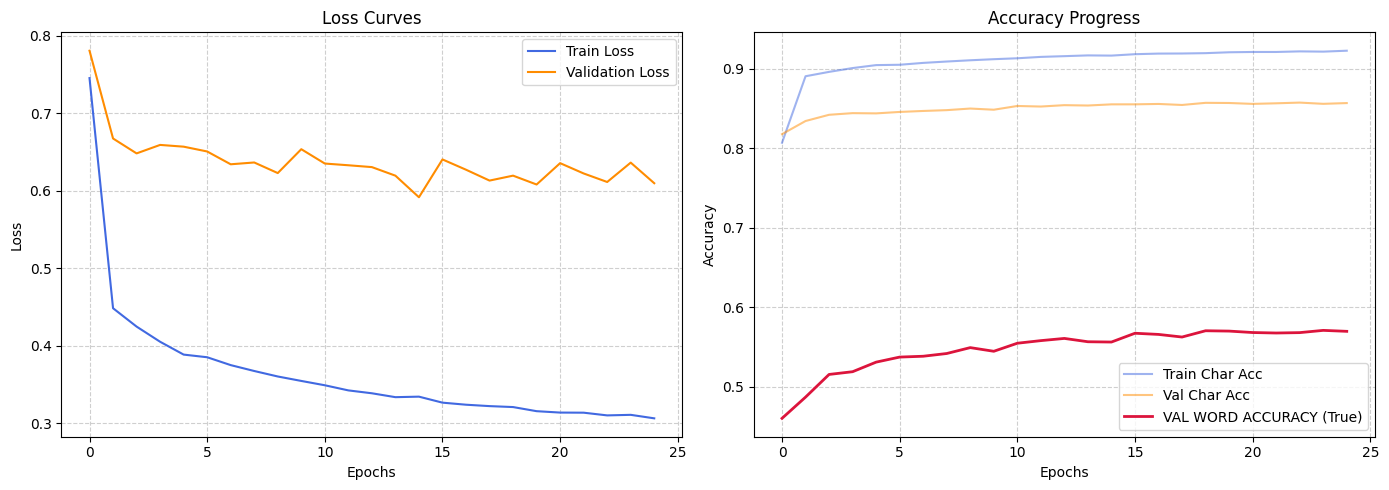

In [43]:
VOCAB_SIZE = len(vocab)
EMBED_SIZE = 128
HIDDEN_SIZE = 256 
DROPOUT = 0.2     
EPOCHS = 25
LEARNING_RATE = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing sequence pipeline calculations on target backend: {device}")

# Reverse mapping to decode integers back to Georgian characters
idx2char = {v: k for k, v in char2idx.items()}

# Initialize components
attention = Attention(HIDDEN_SIZE // 2, HIDDEN_SIZE // 2) 
encoder_network = Encoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE // 2, DROPOUT)
decoder_network = Decoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE // 2, DROPOUT, attention)
model = Seq2Seq(encoder_network, decoder_network, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=char2idx[PAD_TOKEN])

train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_word_accs = [] # Track real word-level accuracy
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    epoch_train_correct = 0
    epoch_train_total = 0
    
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        
        output = model(src, trg, teacher_forcing_ratio=0.5)
        
        output_dim = output.shape[-1]
        loss_output = output[1:].view(-1, output_dim)
        loss_target = trg[1:].view(-1)
        
        loss = criterion(loss_output, loss_target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        epoch_train_loss += loss.item()
        
        preds = loss_output.argmax(dim=1)
        mask = loss_target != char2idx[PAD_TOKEN]
        epoch_train_correct += ((preds == loss_target) & mask).sum().item()
        epoch_train_total += mask.sum().item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_acc = epoch_train_correct / epoch_train_total
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    
    # --- VALIDATION PHASE ---
    model.eval()
    epoch_val_loss = 0
    epoch_val_char_correct = 0
    epoch_val_char_total = 0
    
    epoch_val_word_correct = 0
    epoch_val_word_total = 0
    
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0) 
            
            output_dim = output.shape[-1]
            loss_output = output[1:].view(-1, output_dim)
            loss_target = trg[1:].view(-1)
            
            loss = criterion(loss_output, loss_target)
            epoch_val_loss += loss.item()
            
            # 1. Calculate Character-Level Metrics (for gradients/loss context)
            char_preds = loss_output.argmax(dim=1)
            char_mask = loss_target != char2idx[PAD_TOKEN]
            epoch_val_char_correct += ((char_preds == loss_target) & char_mask).sum().item()
            epoch_val_char_total += char_mask.sum().item()
            
            # 2. Calculate Real Word-Level Accuracy
            # Reshape predictions and targets back to batches: [batch_size, sequence_length]
            pred_sequences = output.argmax(dim=2).permute(1, 0) 
            trg_sequences = trg.permute(1, 0)                   
            
            for i in range(pred_sequences.shape[0]):
                # Decode target word string
                target_word = ""
                for tok in trg_sequences[i][1:]: # Skip <SOS>
                    t_idx = tok.item()
                    if t_idx == char2idx[EOS_TOKEN] or t_idx == char2idx[PAD_TOKEN]:
                        break
                    target_word += idx2char.get(t_idx, "")
                
                # Decode predicted word string
                pred_word = ""
                for tok in pred_sequences[i][1:]: # Skip <SOS> position
                    p_idx = tok.item()
                    if p_idx == char2idx[EOS_TOKEN] or p_idx == char2idx[PAD_TOKEN]:
                        break
                    pred_word += idx2char.get(p_idx, "")
                
                # Strict string match validation
                if pred_word == target_word:
                    epoch_val_word_correct += 1
                epoch_val_word_total += 1
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_char_acc = epoch_val_char_correct / epoch_val_char_total
    avg_val_word_acc = epoch_val_word_correct / epoch_val_word_total
    
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_char_acc)
    val_word_accs.append(avg_val_word_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Char Acc: {avg_train_acc:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Char Acc:   {avg_val_char_acc:.4f} | [!!!] VAL WORD ACC: {avg_val_word_acc:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'georgian_spellchecker_attn.pth')
        print("--> Checkpoint saved successfully!")

# Modified Plotting Block to include Word Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='royalblue')
plt.plot(val_losses, label='Validation Loss', color='darkorange')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Char Acc', color='royalblue', alpha=0.5)
plt.plot(val_accs, label='Val Char Acc', color='darkorange', alpha=0.5)
plt.plot(val_word_accs, label='VAL WORD ACCURACY (True)', color='crimson', linewidth=2)
plt.title('Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()